<h1> constructing dataset! </h1>

In [41]:
import os
import glob
import time
import random
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras import layers, Sequential
from tensorflow.keras.utils import plot_model

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_fscore_support
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc

In [42]:
warnings.filterwarnings("ignore")
plt.style.use('dark_background')

In [43]:
class CFG:
    EPOCHS = 10
    BATCH_SIZE = 32
    SEED = 42
    TF_SEED = 768
    HEIGHT = 224
    WIDTH = 224
    CHANNELS = 3
    IMAGE_SIZE = (224, 224, 3)

In [44]:
def seed_everything(seed=CFG.SEED):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

seed_everything(CFG.SEED)

In [45]:
# Download latest version and move to project directory
import kagglehub
import shutil

# Download to default cache location first
temp_path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

# Set custom download path to your project folder
custom_path = "/Users/anixas./Desktop/Projects/prsf_26/dataset"
os.makedirs(custom_path, exist_ok=True)

# Copy the dataset to your project folder
if os.path.exists(temp_path):
    dataset_name = os.path.basename(temp_path)
    final_path = os.path.join(custom_path, dataset_name)

    if not os.path.exists(final_path):
        shutil.copytree(temp_path, final_path)
        print(f"Dataset copied to: {final_path}")
    else:
        print(f"Dataset already exists at: {final_path}")

    path = final_path
else:
    print("Download failed")
    path = temp_path

print("Path to dataset files:", path)

Dataset already exists at: /Users/anixas./Desktop/Projects/prsf_26/dataset/2
Path to dataset files: /Users/anixas./Desktop/Projects/prsf_26/dataset/2
Dataset already exists at: /Users/anixas./Desktop/Projects/prsf_26/dataset/2
Path to dataset files: /Users/anixas./Desktop/Projects/prsf_26/dataset/2


In [46]:
# Define paths based on custom download location
DATASET_PATH = path + "/"
TRAIN_PATH = path + '/chest_xray/train/'
VAL_PATH = path + '/chest_xray/val/'
TEST_PATH = path + '/chest_xray/test/'

# Checking dataset and locations
print(f"Dataset will be downloaded to: {path}")
print(f"Train path: {TRAIN_PATH}")
print(f"Val path: {VAL_PATH}")
print(f"Test path: {TEST_PATH}")

Dataset will be downloaded to: /Users/anixas./Desktop/Projects/prsf_26/dataset/2
Train path: /Users/anixas./Desktop/Projects/prsf_26/dataset/2/chest_xray/train/
Val path: /Users/anixas./Desktop/Projects/prsf_26/dataset/2/chest_xray/val/
Test path: /Users/anixas./Desktop/Projects/prsf_26/dataset/2/chest_xray/test/


In [47]:
# Generate a summary of the dataset
print('DATASET SUMMARY')
print('========================\n')
for dirpath, dirnames, filenames in os.walk(DATASET_PATH):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}")
print('\n========================')

DATASET SUMMARY

There are 1 directories and 0 images in /Users/anixas./Desktop/Projects/prsf_26/dataset/2/
There are 5 directories and 0 images in /Users/anixas./Desktop/Projects/prsf_26/dataset/2/chest_xray
There are 2 directories and 0 images in /Users/anixas./Desktop/Projects/prsf_26/dataset/2/chest_xray/test
There are 0 directories and 390 images in /Users/anixas./Desktop/Projects/prsf_26/dataset/2/chest_xray/test/PNEUMONIA
There are 0 directories and 234 images in /Users/anixas./Desktop/Projects/prsf_26/dataset/2/chest_xray/test/NORMAL
There are 3 directories and 1 images in /Users/anixas./Desktop/Projects/prsf_26/dataset/2/chest_xray/chest_xray
There are 2 directories and 1 images in /Users/anixas./Desktop/Projects/prsf_26/dataset/2/chest_xray/chest_xray/test
There are 0 directories and 390 images in /Users/anixas./Desktop/Projects/prsf_26/dataset/2/chest_xray/chest_xray/test/PNEUMONIA
There are 0 directories and 234 images in /Users/anixas./Desktop/Projects/prsf_26/dataset/2/ch

In [48]:
# time
train_images = glob.glob(f"{TRAIN_PATH}**/*.jpeg")
val_images = glob.glob(f"{VAL_PATH}**/*.jpeg")
test_images = glob.glob(f"{TEST_PATH}**/*.jpeg")

In [49]:
train_size = len(train_images)
val_size = len(val_images)
test_size = len(test_images)
total = train_size + val_size + test_size

# View the counts
print(f'train samples count:\t\t{train_size}')
print(f'dev/validation samples count:\t{val_size}')
print(f'test samples count:\t\t{test_size}')
print('=======================================')
print(f'TOTAL:\t\t\t\t{total}')

train samples count:		5216
dev/validation samples count:	16
test samples count:		624
TOTAL:				5856


In [50]:
def generate_labels(image_paths):
    labels = []
    for _ in image_paths:
        if ('PNEUMONIA' in _.replace('chest-xray-pneumonia', '')):
            labels.append('PNEUMONIA')
        else:
            labels.append('NORMAL')
            
    return labels

def build_df(image_paths, labels):
    df = pd.DataFrame({
        'image_path': image_paths,
        'label': generate_labels(labels)
    })
    df['label_encoded'] = df.apply(lambda row: 0 if row.label == 'NORMAL' else 1, axis=1)
    
    return df.sample(frac=1, random_state=CFG.SEED).reset_index()

In [51]:
# Build the DataFrames
train_df = build_df(train_images, generate_labels(train_images))
val_df = build_df(val_images, generate_labels(val_images))
test_df = build_df(test_images, generate_labels(test_images))

In [52]:
# Have a look at val_df
val_df

,index,image_path,label,label_encoded
0,0,/Users/anixas./Desktop/Projects/prsf_26/datase...,PNEUMONIA,1
1,1,/Users/anixas./Desktop/Projects/prsf_26/datase...,PNEUMONIA,1
2,5,/Users/anixas./Desktop/Projects/prsf_26/datase...,PNEUMONIA,1
3,14,/Users/anixas./Desktop/Projects/prsf_26/datase...,NORMAL,0
4,13,/Users/anixas./Desktop/Projects/prsf_26/datase...,NORMAL,0
5,11,/Users/anixas./Desktop/Projects/prsf_26/datase...,NORMAL,0
6,8,/Users/anixas./Desktop/Projects/prsf_26/datase...,NORMAL,0
7,9,/Users/anixas./Desktop/Projects/prsf_26/datase...,NORMAL,0
8,2,/Users/anixas./Desktop/Projects/prsf_26/datase...,PNEUMONIA,1
9,15,/Users/anixas./Desktop/Projects/prsf_26/datase...,NORMAL,0


In [53]:
def _load(image_path):
    # Read and decode an image file to a uint8 tensor
    image = tf.io.read_file(image_path)
    image = tf.io.decode_jpeg(image, channels=3)
    
    # Resize image
    image = tf.image.resize(image, [CFG.HEIGHT, CFG.WIDTH],
                            method=tf.image.ResizeMethod.LANCZOS3)
    
    # Convert image dtype to float32 and NORMALIZE!!!
    image = tf.cast(image, tf.float32)/255.
    
    # Return image
    return image

def view_sample(image, label, color_map='gray', fig_size=(8, 10)):
    plt.figure(figsize=fig_size)
    plt.imshow(image, cmap=color_map)
    plt.title(f'Label: {label}', fontsize=16)
    return

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.15155439..1.1641732].


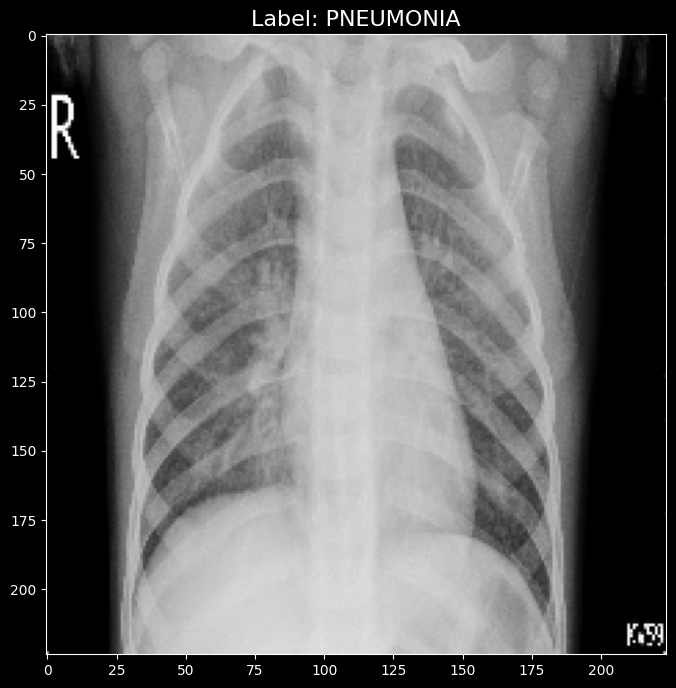

In [54]:
# Select random sample from train_df
idx = random.sample(train_df.index.to_list(), 1)[0]

# Load the random sample and label
sample_image, sample_label = _load(train_df.image_path[idx]), train_df.label[idx]

# View the random sample
view_sample(sample_image, sample_label)

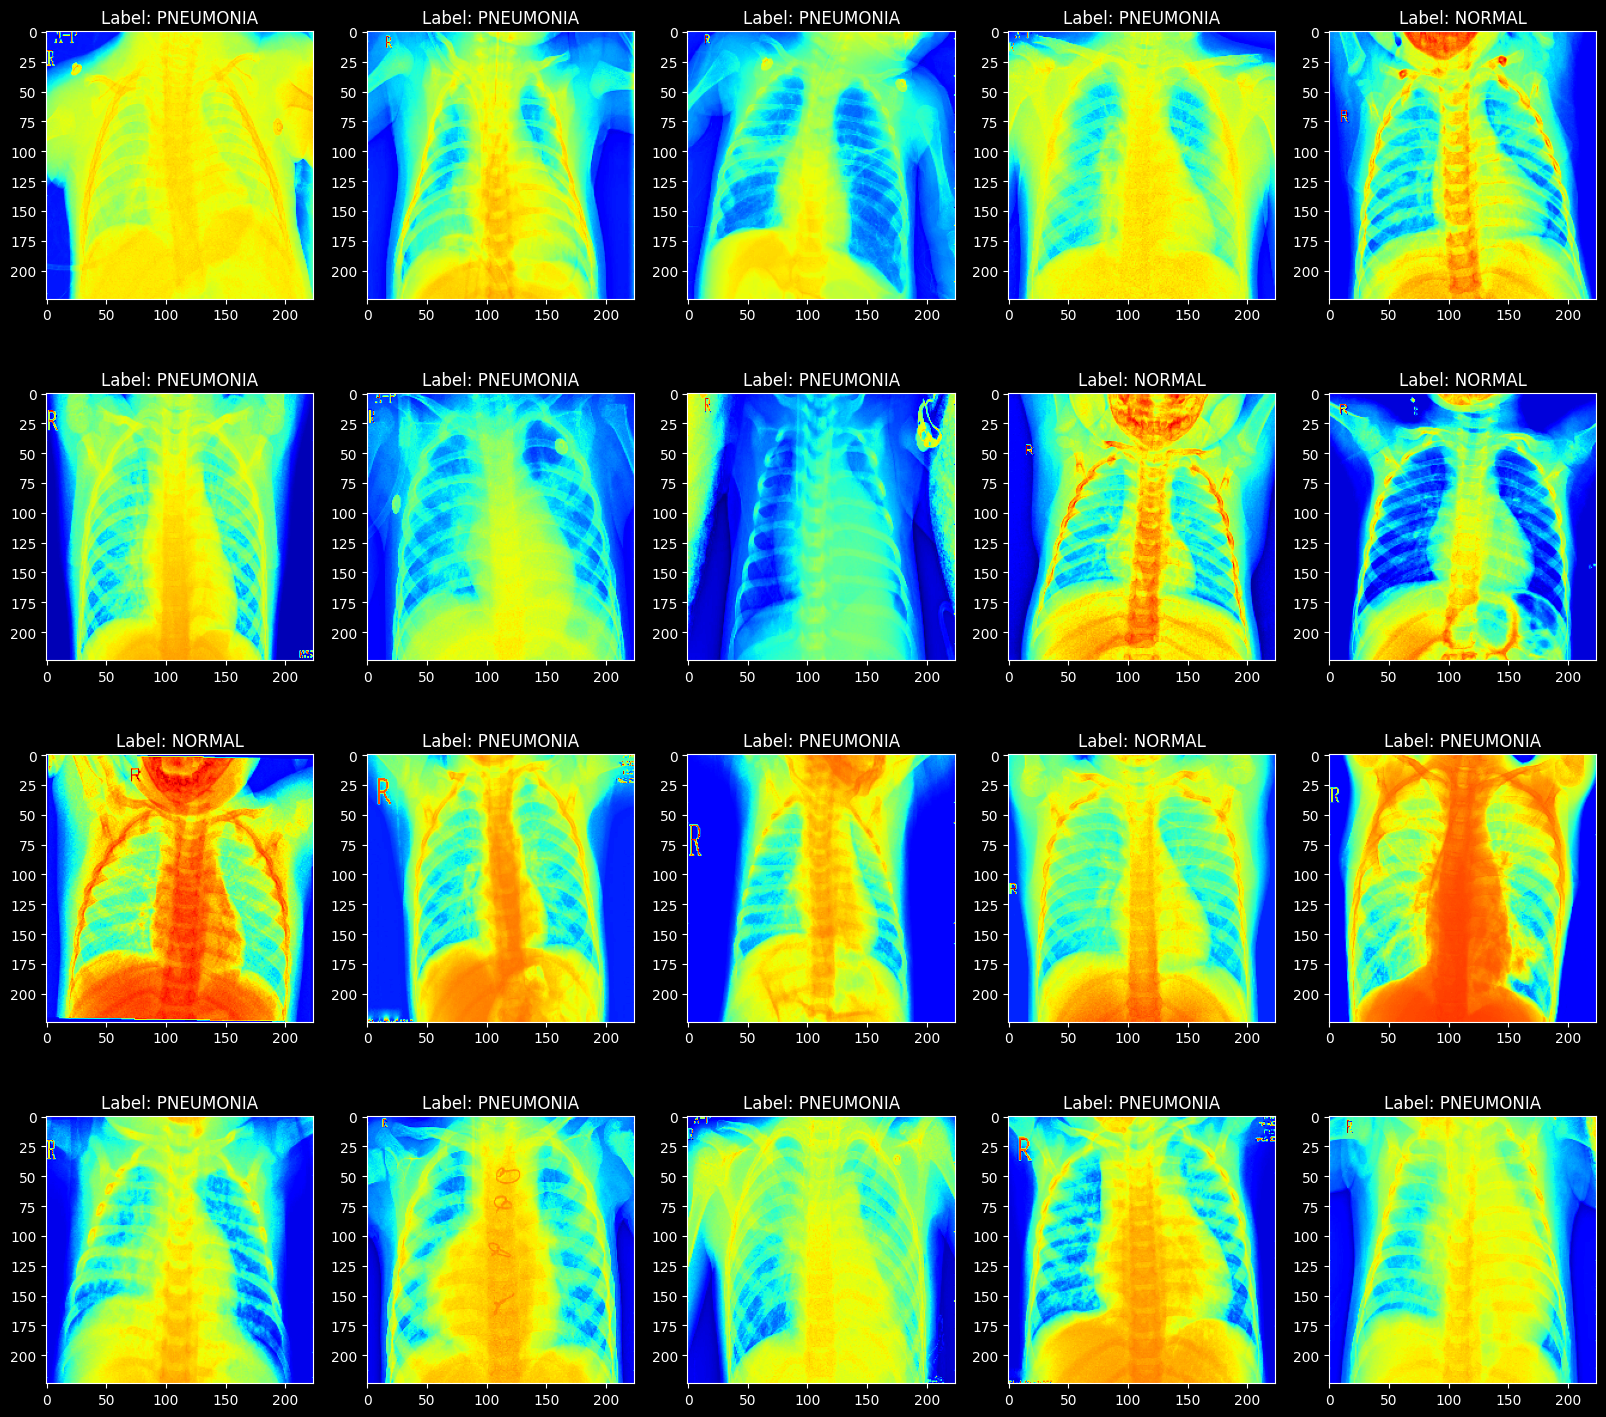

In [55]:
def view_mulitiple_samples(df, sample_loader, count=10, color_map='gray', fig_size=(14, 10)):
    rows = count//5
    if count%5 > 0:
        rows +=1
    
    idx = random.sample(df.index.to_list(), count)    
    fig = plt.figure(figsize=fig_size)

    for column, _ in enumerate(idx):
        plt.subplot(rows, 5, column+1)
        plt.title(f'Label: {df.label[_]}')
        plt.imshow(tf.image.rgb_to_grayscale(sample_loader(df.image_path[_])), cmap=color_map);
    
    return

view_mulitiple_samples(train_df, _load, 
                       count=20, color_map='jet', 
                       fig_size=(20, 18))

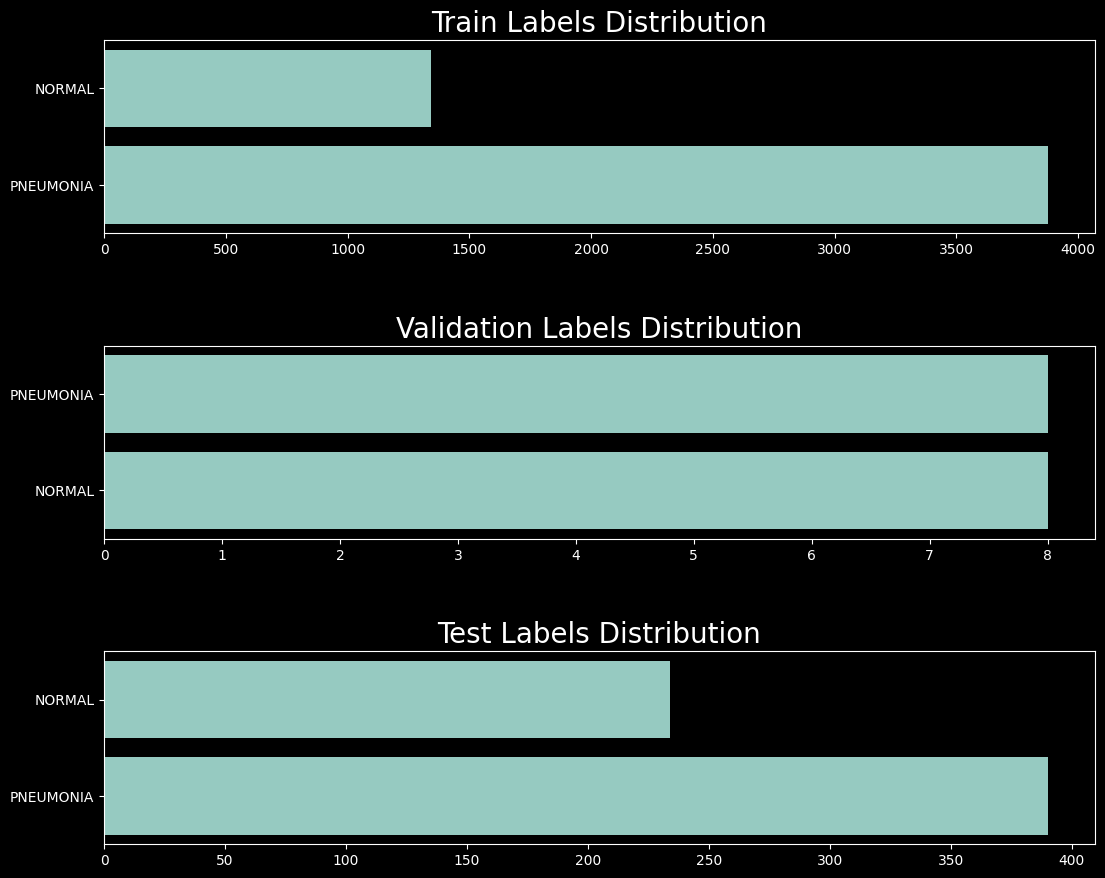

In [56]:
fig, (ax1, ax2, ax3) = plt.subplots(3, figsize=(12, 10))

# Set the spacing between subplots
fig.tight_layout(pad=6.0)

# Plot Train Class Distribution
ax1.set_title('Train Labels Distribution', fontsize=20)
train_distribution = train_df['label'].value_counts().sort_values()

sns.barplot(x=train_distribution.values,
            y=list(train_distribution.keys()),
            orient="h",
            ax=ax1)

# Plot Validation Class Distribution
ax2.set_title('Validation Labels Distribution', fontsize=20)
val_distribution = val_df['label'].value_counts().sort_values()

sns.barplot(x=val_distribution.values,
            y=list(val_distribution.keys()),
            orient="h",
            ax=ax2)

# Plot Test Class Distribution
ax3.set_title('Test Labels Distribution', fontsize=20)
test_distribution = test_df['label'].value_counts().sort_values()

sns.barplot(x=test_distribution.values,
            y=list(test_distribution.keys()),
            orient="h",
            ax=ax3);

In [57]:
# new train and validation split
train_pneumonia = train_df[train_df['label'] == 'PNEUMONIA']
train_normal = train_df[train_df['label'] == 'NORMAL']

# Create chronological ordered split
validation_size = 0.2

# Get new validation samples
val_pneumonia = train_pneumonia[:int(len(train_pneumonia) * validation_size)]
val_normal = train_normal[:int(len(train_normal) * validation_size)]

# Get new train samples
train_new_pneumonia = train_pneumonia[int(len(train_pneumonia) * validation_size):]
train_new_normal = train_normal[int(len(train_normal) * validation_size):]

# Create new validation set and shuffle
val_split_df = pd.concat([val_df, val_pneumonia, val_normal], axis=0) \
                 .sample(frac=1, random_state=CFG.SEED) \
                 .reset_index(drop=True)

# Create new train set and shuffle
train_split_df = pd.concat([train_new_pneumonia, train_new_normal], axis=0) \
                   .sample(frac=1, random_state=CFG.SEED) \
                   .reset_index(drop=True) 

In [58]:
# View fisrt 10 samples from the new validation set
val_split_df.head(10)

,index,image_path,label,label_encoded
0,2380,/Users/anixas./Desktop/Projects/prsf_26/datase...,PNEUMONIA,1
1,803,/Users/anixas./Desktop/Projects/prsf_26/datase...,PNEUMONIA,1
2,3307,/Users/anixas./Desktop/Projects/prsf_26/datase...,PNEUMONIA,1
3,2478,/Users/anixas./Desktop/Projects/prsf_26/datase...,PNEUMONIA,1
4,3939,/Users/anixas./Desktop/Projects/prsf_26/datase...,NORMAL,0
5,4559,/Users/anixas./Desktop/Projects/prsf_26/datase...,NORMAL,0
6,1890,/Users/anixas./Desktop/Projects/prsf_26/datase...,PNEUMONIA,1
7,745,/Users/anixas./Desktop/Projects/prsf_26/datase...,PNEUMONIA,1
8,1745,/Users/anixas./Desktop/Projects/prsf_26/datase...,PNEUMONIA,1
9,1032,/Users/anixas./Desktop/Projects/prsf_26/datase...,PNEUMONIA,1


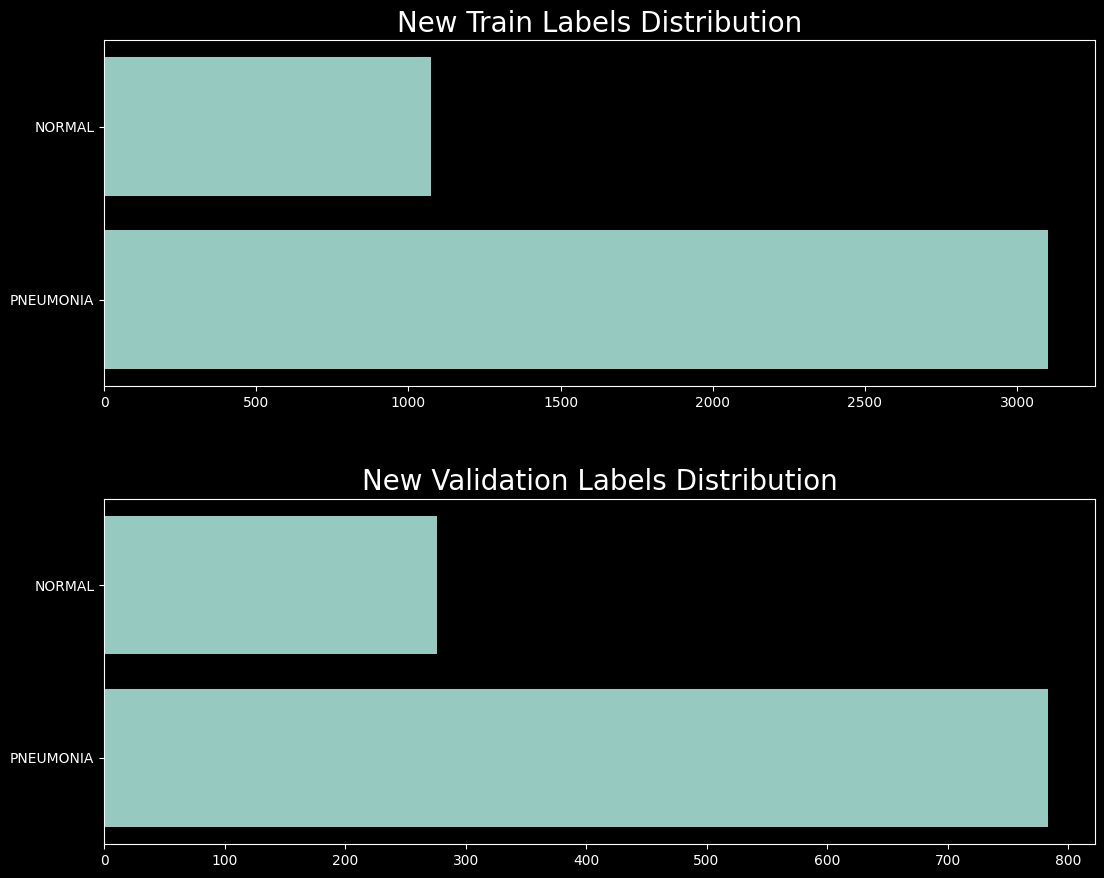

In [59]:
fig, (ax1, ax2) = plt.subplots(2, figsize=(12, 10))

# Set the spacing between subplots
fig.tight_layout(pad=6.0)

# Plot Train Class Distribution
ax1.set_title('New Train Labels Distribution', fontsize=20)
train_split_distribution = train_split_df['label'].value_counts().sort_values()
sns.barplot(x=train_split_distribution.values,
            y=list(train_split_distribution.keys()),
            orient="h",
            ax=ax1);

# Plot Validation Class Distribution
ax2.set_title('New Validation Labels Distribution', fontsize=20)
val_split_distribution = val_split_df['label'].value_counts().sort_values()
sns.barplot(x=val_split_distribution.values,
            y=list(val_split_distribution.keys()),
            orient="h",
            ax=ax2);

In [60]:
# Constructing dataset input pipeline with tf.data api
# Build augmentation layer
augmentation_layer = Sequential([
    layers.RandomFlip(mode='horizontal_and_vertical', seed=CFG.TF_SEED),
    layers.RandomZoom(height_factor=(-0.1, 0.2), width_factor=(-0.1, 0.2)),
], name='augmentation_layer')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.15155439..1.1641732].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.12858026..1.0743566].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.12858026..1.0743566].


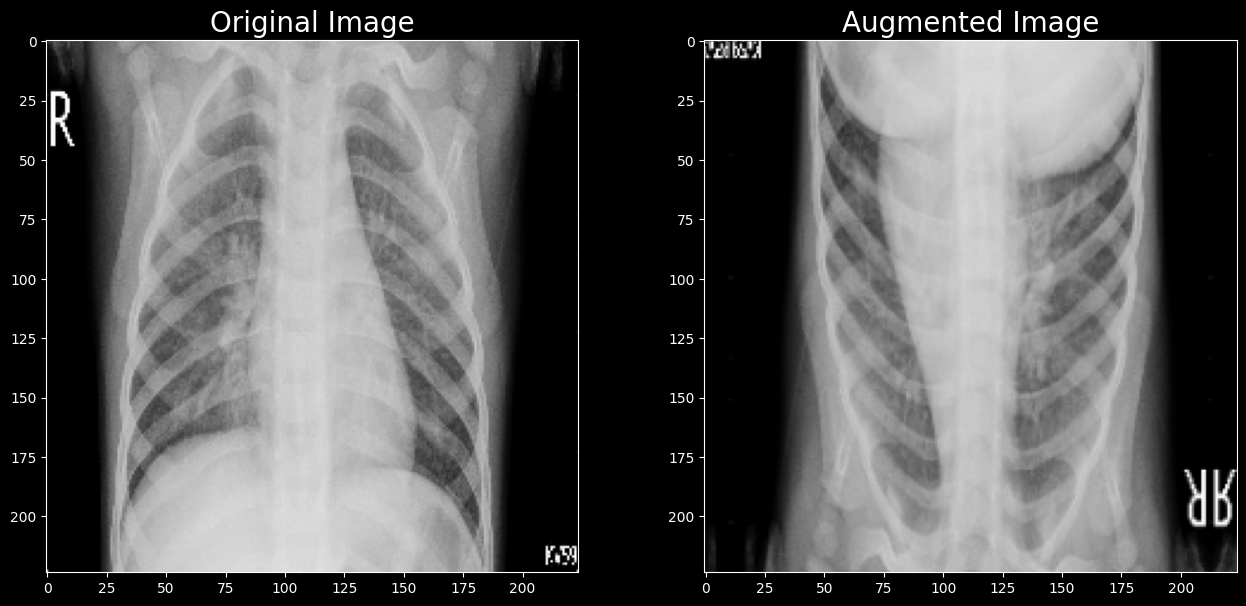

In [61]:
# to make images more clear for model analyses
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 10))

# Set the spacing between subplots
fig.tight_layout(pad=6.0)

# View Original Image
ax1.set_title('Original Image', fontsize=20)
ax1.imshow(sample_image);

# View Augmented Image
ax2.set_title('Augmented Image', fontsize=20)
ax2.imshow(augmentation_layer(sample_image));

<h1> CNN model </h1>

In [ ]:
def cnn_model():
    
    initializer = tf.keras.initializers.GlorotNormal()
    
    cnn_sequential = Sequential([
        layers.Input(shape=CFG.IMAGE_SIZE, dtype=tf.float32, name='input_image'),
        
        layers.Conv2D(8, kernel_size=3, activation='relu', kernel_initializer=initializer),
        layers.Conv2D(8, kernel_size=3, activation='relu', kernel_initializer=initializer),
        layers.MaxPool2D(pool_size=2, padding='valid'),
        
        layers.Conv2D(8, kernel_size=3, activation='relu', kernel_initializer=initializer),
        layers.Conv2D(8, kernel_size=3, activation='relu', kernel_initializer=initializer),
        layers.MaxPool2D(pool_size=2),
        
        layers.Flatten(),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid', kernel_initializer=initializer)
    ], name='cnn_sequential_model')
    
    return cnn_sequential

In [82]:
# Generate Model
model_cnn = cnn_model()

# Generate Summary of the Model
model_cnn.summary()

Model: "cnn_sequential_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 222, 222, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 220, 220, 8)    │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 110, 110, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 108, 108, 8)    │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 106, 106, 8)    │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 53, 53, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 22472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 22472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │        22,473 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,449 (95.50 KB)

 Trainable params: 24,449 (95.50 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
# Explore model visually
plot_model(
    model_cnn, dpi=60,
    show_shapes=True
)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [81]:
# Train the model
def train_model(model, num_epochs, callbacks_list, tf_train_data, 
                tf_valid_data=None, shuffling=False):
    '''
        Trains a TensorFlow model and returns a dict object containing the model metrics history data. 
        
        @params
        - model: (tf.keras.model) -> model to be trained 
        - num_epochs: (int) -> number of epochs to train the model
        - callbacks_list: (list) -> list containing callback fuctions for model
        - tf_train_data: (tf.data.Dataset) -> dataset for model to be train on 
        - tf_valid_data: (tf.data.Dataset) -> dataset for model to be validated on (default=None)
        - shuffling: (bool) -> condition for data shuffling, data is shuffled when True (default=False)
        
        @returns
        - model_history: (dict) -> dictionary containing loss and metrics values tracked during training
    '''
    
    model_history = {}
    
    if tf_valid_data != None:
        model_history = model.fit(tf_train_data,
                                  epochs=num_epochs,
                                  validation_data=tf_valid_data,
                                  validation_steps=int(len(tf_valid_data)),
                                  callbacks=callbacks_list,
                                  shuffle=shuffling)
        
    if tf_valid_data == None:
        model_history = model.fit(tf_train_data,
                                  epochs=num_epochs,
                                  callbacks=callbacks_list,
                                  shuffle=shuffling)
    return model_history

In [66]:
early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True)

reduce_lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    patience=2,
    factor=0.1,
    verbose=1)

EPOCHS = CFG.EPOCHS
CALLBACKS = [early_stopping_callback, reduce_lr_callback]
METRICS = ['accuracy']

In [87]:
# Create TensorFlow datasets
train_ds = tf.data.Dataset.from_tensor_slices((train_split_df['image_path'], train_split_df['label_encoded']))
train_ds = train_ds.map(lambda x, y: (_load(x), y))
train_ds = train_ds.map(lambda x, y: (augmentation_layer(x), y))
train_ds = train_ds.batch(CFG.BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_split_df['image_path'], val_split_df['label_encoded']))
val_ds = val_ds.map(lambda x, y: (_load(x), y))
val_ds = val_ds.batch(CFG.BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_df['image_path'], test_df['label_encoded']))
test_ds = test_ds.map(lambda x, y: (_load(x), y))
test_ds = test_ds.batch(CFG.BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [83]:
tf.random.set_seed(CFG.SEED)

# Compile the model
model_cnn.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=METRICS
)

# Train the model
print(f'Training {model_cnn.name}.')
print(f'Train on {len(train_split_df)} samples, validate on {len(val_split_df)} samples.')
print('----------------------------------')

cnn_history = train_model(
    model_cnn, EPOCHS, CALLBACKS, 
    train_ds, val_ds,
    shuffling=False
)

Training cnn_sequential_model.
Train on 4173 samples, validate on 1059 samples.
----------------------------------
Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 61s 456ms/step - accuracy: 0.7476 - loss: 0.5371 - val_accuracy: 0.9065 - val_loss: 0.2276 - learning_rate: 0.0010
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 61s 456ms/step - accuracy: 0.7476 - loss: 0.5371 - val_accuracy: 0.9065 - val_loss: 0.2276 - learning_rate: 0.0010
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 55s 417ms/step - accuracy: 0.9222 - loss: 0.1975 - val_accuracy: 0.9320 - val_loss: 0.1701 - learning_rate: 0.0010
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 55s 417ms/step - accuracy: 0.9222 - loss: 0.1975 - val_accuracy: 0.9320 - val_loss: 0.1701 - learning_rate: 0.0010
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 53s 401ms/step - accuracy: 0.9167 - loss: 0.1978 - val_accuracy: 0.9254 - val_loss: 0.1902 - learning_rate: 0.0010
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 53s 401ms/step - accuracy: 0.9167 - loss: 0.1978 - val_accuracy: 0.925

In [88]:
# Evaluate the model
cnn_evaluation = model_cnn.evaluate(test_ds)

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - accuracy: 0.7843 - loss: 0.6032
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - accuracy: 0.7843 - loss: 0.6032


In [89]:
# Generate model probabilities and associated predictions
cnn_test_probabilities = model_cnn.predict(test_ds, verbose=1)
cnn_test_predictions = tf.argmax(cnn_test_probabilities, axis=1)

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step


In [69]:
# The function to get any model/preprocessor from tensorflow hub
def get_tfhub_model(model_link, model_name, model_trainable=False):
    return hub.KerasLayer(model_link,
                          trainable=model_trainable,
                          name=model_name)

<h1> resnet model code! </h1>

In [86]:
# Generate model
resnet50v2_url = 'https://tfhub.dev/google/imagenet/resnet_v2_50/feature_vector/5'
model_name = 'resnet50_v2'
set_trainable=False # set trainable to False for inference-only 

resnet50_v2 = get_tfhub_model(resnet50v2_url, model_name, model_trainable=set_trainable)

In [ ]:
# Define the model
def resnet_model():
    resnet_sequential = Sequential([
        layers.Input(shape=CFG.IMAGE_SIZE, dtype=tf.float32, name='input_image'),
        resnet50_v2,
        layers.Dropout(0.2),
        layers.Dense(2, activation='sigmoid', dtype=tf.float32)
    ], name='resnet_sequential_model')
    
    return resnet_sequential

In [ ]:
# Generate Model
model_resnet = resnet_model()

# Generate Summary of the Model
model_resnet.summary()

In [ ]:
tf.random.set_seed(CFG.SEED)

# Compile the model
model_resnet.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=METRICS
)

# Train the model
print(f'Training {model_resnet.name}.')
print(f'Train on {len(train_split_df)} samples, validate on {len(val_split_df)} samples.')
print('----------------------------------')

resnet_history = train_model(
    model_resnet, EPOCHS, CALLBACKS,
    train_ds, val_ds,
    shuffling=False
)

In [ ]:
# Evaluate the model
resnet_evaluation = model_resnet.evaluate(test_ds)

In [ ]:
# Generate model probabilities and associated predictions
resnet_test_probabilities = model_resnet.predict(test_ds, verbose=1)
resnet_test_predictions = tf.argmax(resnet_test_probabilities, axis=1)